# California Housing — Feature Engineering 실습 

**California Housing** 데이터셋을 사용하여, 원본 Feature만으로 만든
Baseline 모델과, 파생변수(derived feature)를 추가한 모델의 성능을 직접 비교합니다.

- **데이터셋**: California Housing (1990년 캘리포니아 인구조사 기반, 블록 그룹 단위 집계)
- **Target**: `MedHouseVal` (블록 그룹의 중위 주택 가격, 단위 10만 달러)
- **문제 유형**: 회귀(Regression) — 연속적인 숫자(집값)를 예측
- **이번 실습의 목표**:
  1. 원본 8개 Feature만 사용한 Baseline 모델을 만든다.
  2. 원본 Feature들 사이에 숨어 있는 관계를 파생변수로 명시적으로 표현한다.
  3. Baseline과 Feature Engineering 적용 모델의 성능을 공정하게 비교한다.
  4. 어떤 파생변수가 실제로 효과가 있었는지 Feature Importance로 검증한다.

## Feature Engineering이란?

> "Feature Engineering은 단순히 컬럼을 추가하는 작업이 아니라,
> 기존 데이터를 AI가 더 잘 이해할 수 있는 새로운 정보로 바꾸는 과정입니다."

```

## 1. 라이브러리 불러오기


In [1]:
from __future__ import annotations

from pathlib import Path

import platform
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"

elif system_name == "Darwin":  # macOS
    plt.rcParams["font.family"] = "AppleGothic"

else:  # Linux, Colab, Ubuntu
    plt.rcParams["font.family"] = "NanumGothic"

# 마이너스 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams["figure.dpi"] = 100
print("라이브러리 불러오기 완료")

라이브러리 불러오기 완료


## 2. 데이터 불러오기



In [2]:
df = pd.read_csv("../data/housing.csv")
print(f"데이터 shape: {df.shape}")

데이터 shape: (20640, 9)


## 3. 데이터 확인


In [3]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
print("컬럼 목록:", list(df.columns))
df.info()

컬럼 목록: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [5]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [6]:
print("결측치 개수:")
print(df.isna().sum())
print()
print(f"중복 행 개수: {df.duplicated().sum()}")

결측치 개수:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

중복 행 개수: 0


## 4. Dataset 이해

California Housing 데이터셋은 1990년 캘리포니아 인구조사를 바탕으로, 지리적으로
가까운 가구들을 묶은 "블록 그룹(block group)" 단위로 집계된 데이터입니다. 즉 한 행은
개별 집이 아니라 하나의 지역을 나타냅니다.

| 컬럼 | 의미 | 역할 | 집값과 예상 관계 | 파생변수 생성 가능성 |
|---|---|---|---|---|
| `MedInc` | 지역의 중위 소득 (단위: 만 달러) | Feature | 소득이 높을수록 집값도 높은 강한 양의 관계 예상 | 방 수/인원과 결합해 "구매력" 표현 가능 |
| `HouseAge` | 지역 주택의 중위 연식(년) | Feature | 방향성이 뚜렷하지 않고 위치·소득과 상호작용할 가능성 | 구간화(binning)로 비선형 관계 표현 가능 |
| `AveRooms` | 가구당 평균 방 개수 | Feature | 방이 많을수록 넓은 주택일 가능성 → 양의 관계 예상 | AveOccup, AveBedrms와 비율로 결합 가능 |
| `AveBedrms` | 가구당 평균 침실 개수 | Feature | AveRooms와 강한 상관 → 단독 해석 주의 | 전체 방 대비 침실 비율로 구조 표현 가능 |
| `Population` | 지역 인구수 | Feature | 단독으로는 방향성이 약함 | AveOccup과 결합해 규모/밀집 특성 표현 가능 |
| `AveOccup` | 가구당 평균 거주 인원 | Feature | 값이 클수록(과밀) 저가 주택일 가능성 | AveRooms와 비율로 "공간 여유도" 표현 가능 |
| `Latitude` | 지역의 위도 | Feature | 단독 해석 어려움, Longitude와 결합 필요 | Longitude와 함께 군집화(clustering)로 지역 특성 표현 |
| `Longitude` | 지역의 경도 | Feature | 단독 해석 어려움, Latitude와 결합 필요 | Latitude와 함께 군집화로 지역 특성 표현 |
| `MedHouseVal` | 지역의 중위 주택 가격 (단위: 10만 달러) | **Target** | — | — |

## 5. 간단한 EDA


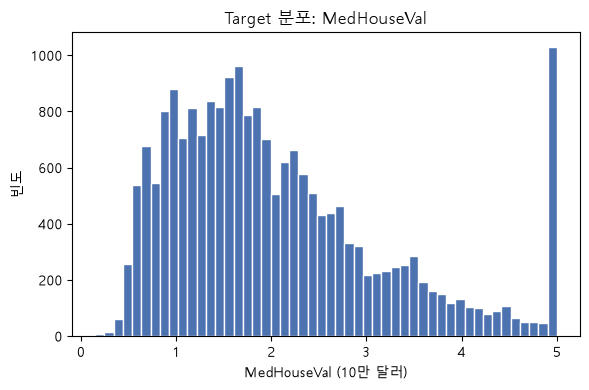

In [7]:
TARGET = "MedHouseVal"
FEATURE_COLUMNS = [
    "MedInc", "HouseAge", "AveRooms", "AveBedrms",
    "Population", "AveOccup", "Latitude", "Longitude",
]

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(df[TARGET], bins=50, color="#4C72B0", edgecolor="white")
ax.set_title("Target 분포: MedHouseVal")
ax.set_xlabel("MedHouseVal (10만 달러)")
ax.set_ylabel("빈도")
plt.tight_layout()
plt.show()

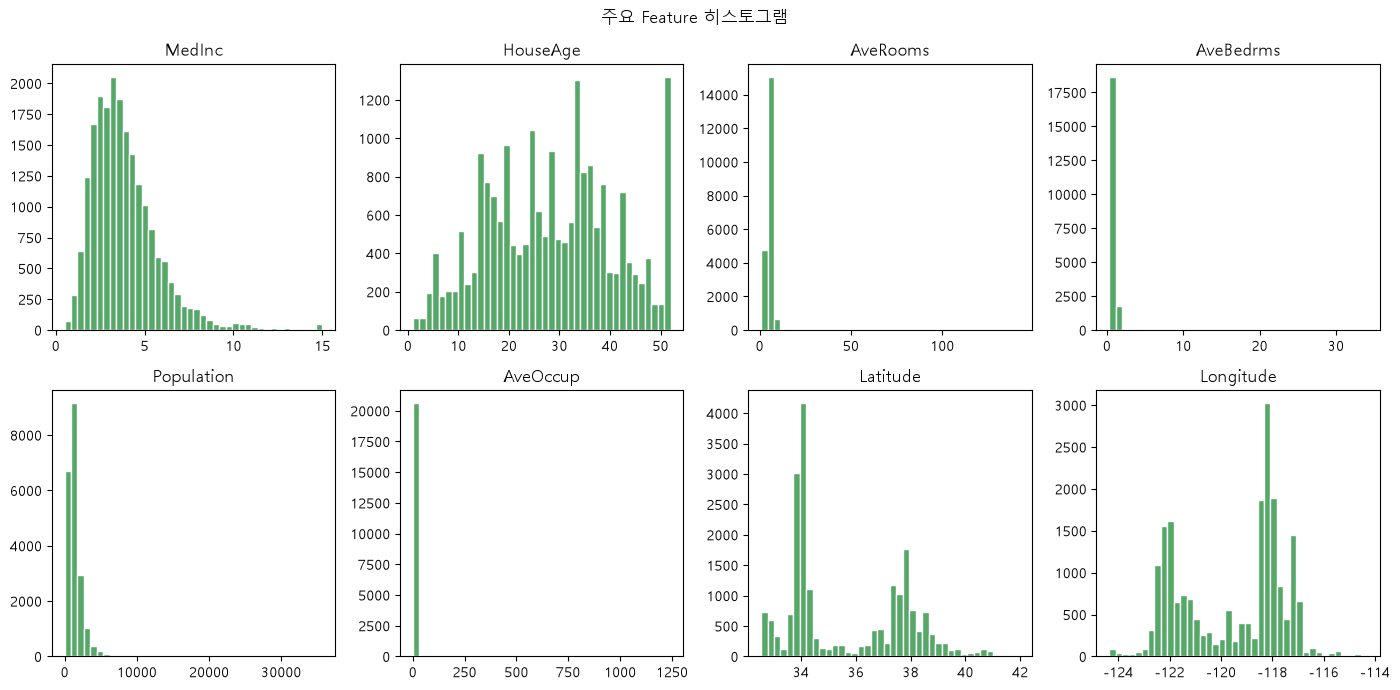

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, col in zip(axes.ravel(), FEATURE_COLUMNS):
    ax.hist(df[col], bins=40, color="#55A868", edgecolor="white")
    ax.set_title(col)
plt.suptitle("주요 Feature 히스토그램")
plt.tight_layout()
plt.show()

**해석**: `MedInc`, `AveRooms`, `AveBedrms`, `Population`, `AveOccup`은 모두
오른쪽으로 긴 꼬리를 가진 분포입니다. 즉 대부분의 지역은 값이 작은 범위에 몰려 있고,
극단적으로 큰 값을 가진 소수의 지역(이상치 후보)이 존재합니다.

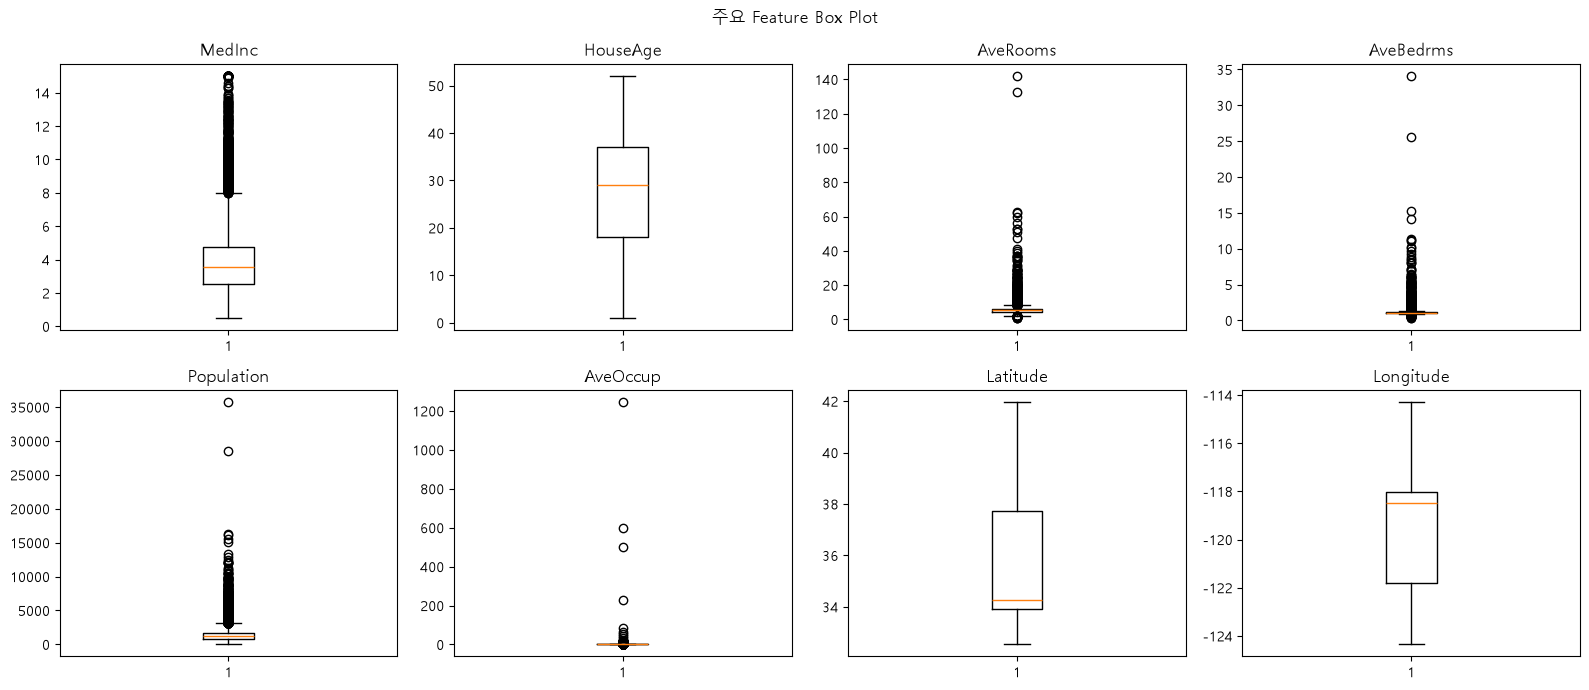

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for ax, col in zip(axes.ravel(), FEATURE_COLUMNS):
    ax.boxplot(
        df[col],
        orientation="vertical"
    )
    ax.set_title(col)

plt.suptitle("주요 Feature Box Plot")
plt.tight_layout()
plt.show()

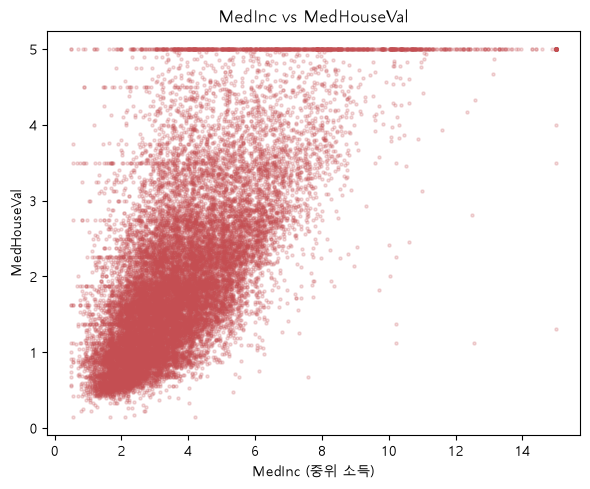

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(df["MedInc"], df[TARGET], s=5, alpha=0.2, color="#C44E52")
ax.set_title("MedInc vs MedHouseVal")
ax.set_xlabel("MedInc (중위 소득)")
ax.set_ylabel("MedHouseVal")
plt.tight_layout()
plt.show()

**해석**: 소득이 높을수록 집값도 대체로 높아지는 뚜렷한 양의 관계가 보입니다.
다만 상단에 값이 수평으로 뭉쳐 있는 부분은 Target 상한선(capping)의 흔적입니다.

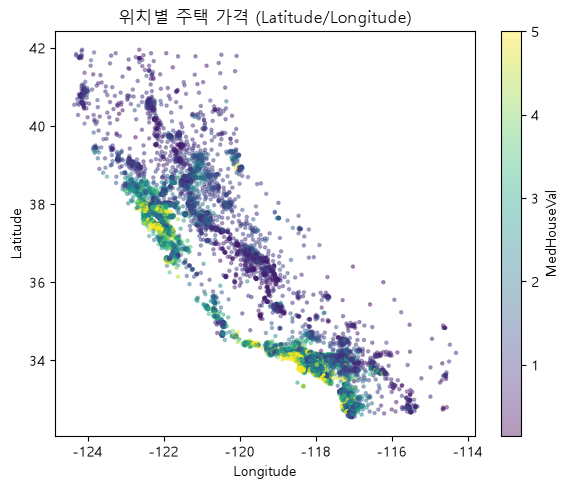

In [12]:
fig, ax = plt.subplots(figsize=(6, 5))
scatter = ax.scatter(
    df["Longitude"], df["Latitude"], c=df[TARGET], cmap="viridis", s=5, alpha=0.4
)
ax.set_title("위치별 주택 가격 (Latitude/Longitude)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.colorbar(scatter, ax=ax, label="MedHouseVal")
plt.tight_layout()
plt.show()

**해석**: 집값이 높은 지역은 특정 좌표(해안가, 대도시 인근)에 뭉쳐 있습니다.
`Latitude`와 `Longitude`를 각각 따로 보는 것보다, 두 값을 함께 사용해 "지역"이라는
개념을 표현해야 이 패턴을 모델에 전달할 수 있습니다.

Target과의 상관계수 (절댓값 기준 정렬):
MedInc        0.688075
AveRooms      0.151948
Latitude     -0.144160
HouseAge      0.105623
AveBedrms    -0.046701
Longitude    -0.045967
Population   -0.024650
AveOccup     -0.023737
Name: MedHouseVal, dtype: float64


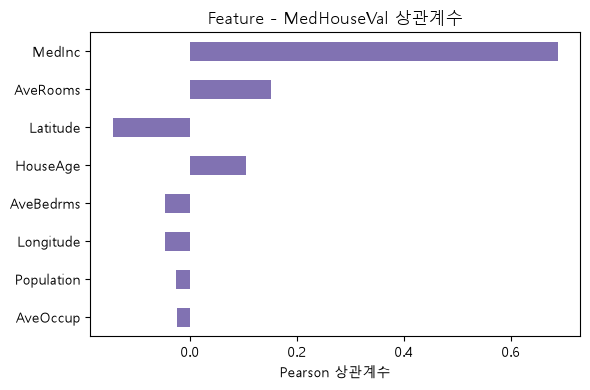

In [13]:
target_corr = df.corr(numeric_only=True)[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
print("Target과의 상관계수 (절댓값 기준 정렬):")
print(target_corr)

fig, ax = plt.subplots(figsize=(6, 4))
target_corr.plot(kind="barh", ax=ax, color="#8172B2")
ax.set_title("Feature - MedHouseVal 상관계수")
ax.set_xlabel("Pearson 상관계수")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

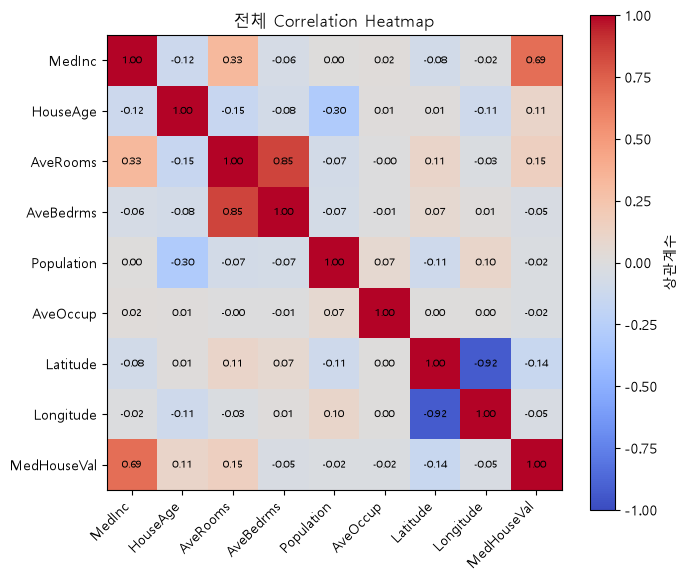

In [14]:
corr_matrix = df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_yticklabels(corr_matrix.columns)
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
ax.set_title("전체 Correlation Heatmap")
plt.colorbar(im, ax=ax, label="상관계수")
plt.tight_layout()
plt.show()

**해석**: `AveRooms`와 `AveBedrms`는 서로 매우 강한 상관관계를 가집니다. 즉 두
컬럼은 상당 부분 같은 정보를 중복해서 담고 있으며, 이 둘의 "비율"을 새로운
Feature로 만들면 중복 대신 새로운 정보(방 구조)를 표현할 수 있습니다.

## 6. EDA Findings

**Finding 1.**
`MedInc`는 `MedHouseVal`과 가장 강한 양의 상관관계를 보인다.

**Finding 2.**
`Latitude`와 `Longitude`는 개별 변수보다 함께 사용했을 때(예: 지도 시각화, 군집화)
지역 특성을 더 잘 표현한다.

**Finding 3.**
`AveRooms`와 `AveBedrms`는 서로 상관관계가 매우 높아, 두 값을 그대로 쓰기보다
비율 Feature로 결합하는 것이 의미 있을 수 있다.

**Finding 4.**
`Population`과 `AveOccup`에는 Box Plot 기준 극단적인 이상치 후보가 다수 존재한다.

**Finding 5.**
`HouseAge`는 Target과의 선형 상관계수가 다른 주요 Feature보다 상대적으로 약해, 단순 선형 관계로 보기 어렵다.
구간화(binning)를 통해 비선형적인 관계를 표현하는 편이 더 적절할 수 있다.

## 7. 파생변수를 만드는 이유


원본 Feature 두 개를 예로 들어보겠습니다.

```text
AveRooms
AveOccup
```

**예시**

```text
집 A
AveRooms = 8
AveOccup = 2

집 B
AveRooms = 8
AveOccup = 8
```

두 지역 모두 `AveRooms`는 8이지만, 실제 거주 여유도는 완전히 다릅니다. 집 A는
가구당 8개의 방에 2명이 살고, 집 B는 같은 8개의 방에 8명이 삽니다. 원본 Feature만
보면 두 지역은 "방이 8개"라는 점에서 동일하게 취급되기 쉽습니다.

따라서 다음 Feature를 만듭니다.

```text
RoomsPerHousehold = AveRooms / AveOccup
```

이 Feature는 단순한 "방 개수"가 아니라, **"거주 인원 대비 공간 여유도"**라는 새로운
정보를 제공합니다.

**원본 Feature만 사용**
- `AveRooms`와 `AveOccup`의 개별 영향을 각각 따로 학습

**파생 Feature 추가**
- 두 변수의 관계(비율)를 학습
- 사람이 이해한 의미("공간 여유도")를 모델에 직접 제공

> "파생변수는 기존 데이터를 복사하는 것이 아니라,
> 기존 변수 사이에 숨어 있는 관계를 명시적으로 표현하는 작업입니다."

## 8. Hypothesis Engineering

**가설 1.**
- 가설: 가구당 방 수(`AveRooms`)가 많을수록 집값이 높을 것이다.
- 왜?: 방이 많다는 것은 대체로 더 넓은 주택을 의미하기 때문이다.
- 검증 방법: `AveRooms`와 `MedHouseVal`의 상관계수 및 산점도 확인
- 예상 결과: 약한~중간 수준의 양의 상관관계
- 실패 가능성: 가구원 수가 함께 늘어나면 "방이 많아도 여유롭지 않은" 경우가 있어 관계가 흐려질 수 있다.
- 대안: `AveOccup`과 결합한 `RoomsPerHousehold` 비율 Feature 사용

**가설 2.**
- 가설: 전체 방 중 침실이 차지하는 비율(`BedroomRatio`)은 주택 구조와 가격을 설명할 수 있다.
- 왜?: 침실 비율이 낮으면 거실/서재 등 부가 공간이 많은 고급 주택 구조일 가능성이 있다.
- 검증 방법: `BedroomRatio` 생성 후 Target과의 상관계수 확인
- 예상 결과: 약한 음의 상관관계(침실 비율이 낮을수록 집값이 높을 가능성)
- 실패 가능성: 지역 전체 집계 데이터이므로 개별 주택 구조 차이가 평균에 희석될 수 있다.
- 대안: 다른 Feature와의 상호작용(예: `MedInc`와 결합)으로 재검증

**가설 3.**
- 가설: 중위소득과 방 수의 비율(`IncomePerRoom`)은 지역의 공간 대비 구매력을 표현할 수 있다.
- 왜?: 같은 소득이라도 방이 적은 지역은 상대적으로 주거 공간에 여유가 없을 수 있다.
- 검증 방법: `IncomePerRoom` 생성 후 상관계수 및 Feature Importance 확인
- 예상 결과: `MedInc` 단독보다 특정 구간에서 더 세밀한 설명력을 가질 것
- 실패 가능성: `AveRooms`가 매우 작은 경우 값이 극단적으로 커지는 이상치 문제가 발생할 수 있다.
- 대안: 값 clip 또는 log 변환

**가설 4.**
- 가설: `HouseAge`는 연속값보다 구간화(binning)했을 때 비선형 관계를 더 잘 표현할 수 있다.
- 왜?: 너무 오래되거나 너무 새 주택 모두 특수한 가격대를 형성할 수 있다(선형 관계로 보기 어려움).
- 검증 방법: 구간별 평균 `MedHouseVal` 비교, 구간화 Feature의 Importance 확인
- 예상 결과: 특정 구간(예: 매우 오래된 주택)에서 뚜렷한 가격 패턴이 나타날 것
- 실패 가능성: 구간을 나누는 기준에 따라 정보가 손실될 수 있다.
- 대안: 구간 개수/경계를 다르게 조정하여 재실험 (실습 문제 3 참고)

**가설 5.**
- 가설: `Latitude`/`Longitude` 기반 지역 군집(`LocationCluster`)은 지역 프리미엄을 표현할 수 있다.
- 왜?: 집값은 좌표 자체보다 "어느 동네인지"에 더 크게 좌우된다.
- 검증 방법: 군집별 평균 `MedHouseVal` 비교, 군집 Feature의 Importance 확인
- 예상 결과: 군집 Feature가 원본 좌표보다 더 직접적인 지역 정보를 제공할 것
- 실패 가능성: 군집 개수(`n_clusters`)가 적절하지 않으면 지역을 지나치게 뭉치거나 과도하게 쪼갤 수 있다.
- 대안: `n_clusters`를 5, 8, 12 등으로 바꿔 비교 (실습 문제 4 참고)

**가설 6.**
- 가설: 고소득 지역 여부(`HighIncomeArea`)는 집값 상승 구간을 표현하는 데 도움이 될 수 있다.
- 왜?: 소득이 특정 임계값을 넘으면 집값이 완만하게 증가하는 대신 급격히 뛰는 구간이 있을 수 있다.
- 검증 방법: `HighIncomeArea` 그룹별 평균 `MedHouseVal` 비교
- 예상 결과: 고소득 그룹의 평균 집값이 뚜렷하게 높을 것
- 실패 가능성: 이미 `MedInc` 자체가 강한 신호이므로, 이진화된 정보가 중복되어 큰 추가 효과가 없을 수 있다.
- 대안: 단일 임계값 대신 다단계 구간화 고려

**가설 7.**
- 가설: 소득, 방 수, 거주 인원을 조합하면 고급 주거지역 후보(`LuxuryHouseCandidate`)를 구분할 수 있다.
- 왜?: 고소득 + 공간 여유 + 낮은 밀집도가 동시에 나타나는 지역은 전형적인 고급 주거지일 가능성이 높다.
- 검증 방법: `LuxuryHouseCandidate` 그룹별 평균 `MedHouseVal` 비교
- 예상 결과: 후보로 분류된 지역의 평균 집값이 유의미하게 높을 것
- 실패 가능성: 조건을 모두 만족하는 지역 수가 너무 적어 통계적으로 불안정할 수 있다.
- 대안: 조건 중 하나를 완화하거나, 개별 조건을 각각 Feature로 사용

## 9. Baseline Model

원본 8개 Feature만 사용하여 Baseline 모델을 학습합니다. 이후 Feature Engineering
적용 모델과 공정하게 비교하기 위해, `train_test_split`의 `test_size`/`random_state`와
`RandomForestRegressor`의 `random_state`/`n_estimators`를 모든 실험에서 동일하게
유지합니다.

In [17]:
X = df[FEATURE_COLUMNS].copy()
y = df[TARGET].copy()

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Train shape: {X_train_raw.shape}, Test shape: {X_test_raw.shape}")

Train shape: (16512, 8), Test shape: (4128, 8)


In [19]:
def evaluate(y_true: pd.Series, y_pred: np.ndarray) -> dict[str, float]:
    '''MAE, RMSE, R2를 계산해 딕셔너리로 반환한다.'''
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "RMSE": rmse, "R2": r2}


baseline_model = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)
baseline_model.fit(X_train_raw, y_train)
baseline_pred = baseline_model.predict(X_test_raw)

baseline_metrics = evaluate(y_test, baseline_pred)
baseline_result = {"Model": "Baseline", **baseline_metrics}

baseline_df = pd.DataFrame([baseline_result])
baseline_df

,Model,MAE,RMSE,R2
0,Baseline,0.32679,0.50429,0.805932


현재 모델은 아무런 Feature Engineering을 적용하지 않은 Baseline 모델입니다. 평균 약 3.3만 달러의 오차를 가지며, 집값의 약 80.6%를 설명합니다. 이제 Feature Engineering을 적용하여 MAE와 RMSE는 더 낮추고, R²는 더 높일 수 있는지 비교해 보겠습니다.

## 10. Feature Engineering — pandas 한 줄씩 직접 실습


### Feature 1. RoomsPerHousehold
- 공식: `AveRooms / AveOccup`
- 생성 이유: 가구(거주 인원) 대비 공간 여유도를 표현한다.
- 주의사항: `AveOccup`이 0이거나 매우 작은 경우 무한대/극단값이 생길 수 있어 안전하게 처리한다.
  

In [22]:
# 먼저 원본 train/test를 그대로 복사해서 "Feature를 추가해 나갈" DataFrame을 준비한다.
# X_train_raw, X_test_raw, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=RANDOM_STATE
# )
X_train_engineered = X_train_raw.copy()
X_test_engineered = X_test_raw.copy()

X_train_engineered.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
14196,3.2596,33.0,5.017657,1.006421,2300.0,3.691814,32.71,-117.03
8267,3.8125,49.0,4.473545,1.041005,1314.0,1.738095,33.77,-118.16
17445,4.1563,4.0,5.645833,0.985119,915.0,2.723214,34.66,-120.48
14265,1.9425,36.0,4.002817,1.033803,1418.0,3.994366,32.69,-117.11
2271,3.5542,43.0,6.268421,1.134211,874.0,2.300000,36.78,-119.80


In [23]:
X_train_engineered["RoomsPerHousehold"] = X_train_engineered["AveRooms"] / X_train_engineered["AveOccup"]
X_test_engineered["RoomsPerHousehold"] = X_test_engineered["AveRooms"] / X_test_engineered["AveOccup"]

# AveOccup이 0에 아주 가까우면 나눗셈 결과가 무한대(inf)가 될 수 있으므로 0으로 바꿔준다.
X_train_engineered["RoomsPerHousehold"] = X_train_engineered["RoomsPerHousehold"].replace([np.inf, -np.inf], np.nan).fillna(0.0)
X_test_engineered["RoomsPerHousehold"] = X_test_engineered["RoomsPerHousehold"].replace([np.inf, -np.inf], np.nan).fillna(0.0)

X_train_engineered[["AveRooms", "AveOccup", "RoomsPerHousehold"]].head()

,AveRooms,AveOccup,RoomsPerHousehold
14196,5.017657,3.691814,1.359130
8267,4.473545,1.738095,2.573820
17445,5.645833,2.723214,2.073224
14265,4.002817,3.994366,1.002116
2271,6.268421,2.300000,2.725400


### Feature 2. BedroomRatio
- 공식: `AveBedrms / AveRooms`
- 생성 이유: 전체 방 중 침실이 차지하는 비율을 표현한다.
- 주의사항: `AveRooms`가 0인 경우를 안전하게 처리한다.

In [24]:
X_train_engineered["BedroomRatio"] = X_train_engineered["AveBedrms"] / X_train_engineered["AveRooms"]
X_test_engineered["BedroomRatio"] = X_test_engineered["AveBedrms"] / X_test_engineered["AveRooms"]

X_train_engineered["BedroomRatio"] = X_train_engineered["BedroomRatio"].replace([np.inf, -np.inf], np.nan).fillna(0.0)
X_test_engineered["BedroomRatio"] = X_test_engineered["BedroomRatio"].replace([np.inf, -np.inf], np.nan).fillna(0.0)

X_train_engineered[["AveBedrms", "AveRooms", "BedroomRatio"]].head()

,AveBedrms,AveRooms,BedroomRatio
14196,1.006421,5.017657,0.200576
8267,1.041005,4.473545,0.232703
17445,0.985119,5.645833,0.174486
14265,1.033803,4.002817,0.258269
2271,1.134211,6.268421,0.180940


### Feature 3. IncomePerRoom
- 공식: `MedInc / AveRooms`
- 생성 이유: 방 하나당 지역 소득 수준을 표현한다.
- 주의사항: `AveRooms`가 매우 작은 경우 이상치가 생길 수 있다.

In [25]:
X_train_engineered["IncomePerRoom"] = X_train_engineered["MedInc"] / X_train_engineered["AveRooms"]
X_test_engineered["IncomePerRoom"] = X_test_engineered["MedInc"] / X_test_engineered["AveRooms"]

X_train_engineered["IncomePerRoom"] = X_train_engineered["IncomePerRoom"].replace([np.inf, -np.inf], np.nan).fillna(0.0)
X_test_engineered["IncomePerRoom"] = X_test_engineered["IncomePerRoom"].replace([np.inf, -np.inf], np.nan).fillna(0.0)

X_train_engineered[["MedInc", "AveRooms", "IncomePerRoom"]].head()

,MedInc,AveRooms,IncomePerRoom
14196,3.2596,5.017657,0.649626
8267,3.8125,4.473545,0.852232
17445,4.1563,5.645833,0.736171
14265,1.9425,4.002817,0.485283
2271,3.5542,6.268421,0.567001


### Feature 4. PopulationPerHousehold
- 공식: `Population / AveOccup`
- 생성 이유: 지역 인구와 평균 거주 인원을 결합해 지역 규모/밀집 특성을 표현한다.
- 주의사항: 이 값은 "가구 수 추정치"에 가까우며, 직접적인 인구밀도(면적당 인구)와는 다르다.

In [26]:
X_train_engineered["PopulationPerHousehold"] = X_train_engineered["Population"] / X_train_engineered["AveOccup"]
X_test_engineered["PopulationPerHousehold"] = X_test_engineered["Population"] / X_test_engineered["AveOccup"]

X_train_engineered["PopulationPerHousehold"] = X_train_engineered["PopulationPerHousehold"].replace([np.inf, -np.inf], np.nan).fillna(0.0)
X_test_engineered["PopulationPerHousehold"] = X_test_engineered["PopulationPerHousehold"].replace([np.inf, -np.inf], np.nan).fillna(0.0)

X_train_engineered[["Population", "AveOccup", "PopulationPerHousehold"]].head()

,Population,AveOccup,PopulationPerHousehold
14196,2300.0,3.691814,623.0
8267,1314.0,1.738095,756.0
17445,915.0,2.723214,336.0
14265,1418.0,3.994366,355.0
2271,874.0,2.300000,380.0


### Feature 5. HouseAgeGroup
- `HouseAge`를 `0~10 / 11~20 / 21~30 / 31~40 / 41~50 / 51 이상` 구간으로 나눈다 (`pd.cut` 사용).
- 구간 경계가 데이터 값이 아닌 고정된 숫자이므로 데이터 누수 걱정 없이 바로 만들 수 있다.
- 범주형 결과는 이후 원-핫 인코딩으로 변환해 모델에 입력한다.

In [30]:
HOUSE_AGE_BINS = [-np.inf, 10, 20, 30, 40, 50, np.inf]
HOUSE_AGE_LABELS = ["0-10", "11-20", "21-30", "31-40", "41-50", "51+"]

X_train_engineered["HouseAgeGroup"] = pd.cut(X_train_engineered["HouseAge"], bins=HOUSE_AGE_BINS, labels=HOUSE_AGE_LABELS)
X_test_engineered["HouseAgeGroup"] = pd.cut(X_test_engineered["HouseAge"], bins=HOUSE_AGE_BINS, labels=HOUSE_AGE_LABELS)

X_train_engineered[["HouseAge", "HouseAgeGroup"]].head()

,HouseAge,HouseAgeGroup
14196,33.0,31-40
8267,49.0,41-50
17445,4.0,0-10
14265,36.0,31-40
2271,43.0,41-50


`HouseAgeGroup`은 문자열 범주이므로, 모델에 넣기 전에 `pd.get_dummies()`로 0/1 컬럼
(원-핫 인코딩)으로 바꿔줍니다. 학습/검증 데이터에 항상 같은 6개 컬럼이 만들어지도록
`categories=HOUSE_AGE_LABELS`로 범주를 고정합니다.

In [31]:
train_house_age_dummies = pd.get_dummies(
    pd.Categorical(X_train_engineered["HouseAgeGroup"], categories=HOUSE_AGE_LABELS),
    prefix="HouseAgeGroup",
)
train_house_age_dummies.index = X_train_engineered.index

test_house_age_dummies = pd.get_dummies(
    pd.Categorical(X_test_engineered["HouseAgeGroup"], categories=HOUSE_AGE_LABELS),
    prefix="HouseAgeGroup",
)
test_house_age_dummies.index = X_test_engineered.index

X_train_engineered = pd.concat([X_train_engineered.drop(columns=["HouseAgeGroup"]), train_house_age_dummies], axis=1)
X_test_engineered = pd.concat([X_test_engineered.drop(columns=["HouseAgeGroup"]), test_house_age_dummies], axis=1)

HOUSE_AGE_DUMMY_COLUMNS = [f"HouseAgeGroup_{label}" for label in HOUSE_AGE_LABELS]
X_train_engineered[HOUSE_AGE_DUMMY_COLUMNS].head()

,HouseAgeGroup_0-10,HouseAgeGroup_0-10,HouseAgeGroup_11-20,HouseAgeGroup_11-20,HouseAgeGroup_21-30,HouseAgeGroup_21-30,HouseAgeGroup_31-40,HouseAgeGroup_31-40,HouseAgeGroup_41-50,HouseAgeGroup_41-50,HouseAgeGroup_51+,HouseAgeGroup_51+
14196,False,False,False,False,False,False,True,True,False,False,False,False
8267,False,False,False,False,False,False,False,False,True,True,False,False
17445,True,True,False,False,False,False,False,False,False,False,False,False
14265,False,False,False,False,False,False,True,True,False,False,False,False
2271,False,False,False,False,False,False,False,False,True,True,False,False


### Feature 6. LocationCluster
`Latitude`/`Longitude`로 KMeans 군집(`n_clusters=8`, `random_state=42`, `n_init=10`)을
만듭니다. **KMeans는 반드시 학습 데이터에만 `fit`**하고, 검증 데이터에는 `predict()`만
적용해 데이터 누수를 방지합니다.

In [48]:
kmeans = KMeans(n_clusters=8, random_state=RANDOM_STATE, n_init=10)
kmeans.fit(X_train_engineered[["Latitude", "Longitude"]])  # 반드시 학습 데이터에만 fit!

X_train_engineered["LocationCluster"] = kmeans.predict(X_train_engineered[["Latitude", "Longitude"]])
X_test_engineered["LocationCluster"] = kmeans.predict(X_test_engineered[["Latitude", "Longitude"]])  # 검증 데이터는 predict()만!

X_train_engineered[["Latitude", "Longitude", "LocationCluster"]].head()

,Latitude,Longitude,LocationCluster
14196,32.71,-117.03,5
8267,33.77,-118.16,1
17445,34.66,-120.48,3
14265,32.69,-117.11,5
2271,36.78,-119.80,4


### Feature 7. HighIncomeArea
공식: `MedInc > 학습 데이터 MedInc 중앙값` → 결과는 0 또는 1. 중앙값도 학습 데이터에서만 계산합니다.

In [49]:
train_medinc_median = X_train_engineered["MedInc"].median()  # 반드시 학습 데이터 기준!
print(f"학습 데이터 MedInc 중앙값: {train_medinc_median:.4f}")

X_train_engineered["HighIncomeArea"] = (X_train_engineered["MedInc"] > train_medinc_median).astype(int)
X_test_engineered["HighIncomeArea"] = (X_test_engineered["MedInc"] > train_medinc_median).astype(int)  # 검증 데이터에도 같은 기준값 적용

X_train_engineered["HighIncomeArea"].value_counts()

학습 데이터 MedInc 중앙값: 3.5458


HighIncomeArea
0    8256
1    8256
Name: count, dtype: int64

### Feature 8. LuxuryHouseCandidate
다음 조건을 모두 만족하면 1, 아니면 0:
- `MedInc`가 학습 데이터 상위 25% 이상
- `RoomsPerHousehold`가 학습 데이터 상위 25% 이상
- `AveOccup`이 학습 데이터 중앙값 이하

이 Feature는 도메인 가설 기반 후보일 뿐이며, 반드시 성능 검증 후 채택 여부를 결정해야 합니다.

In [50]:
train_medinc_p75 = X_train_engineered["MedInc"].quantile(0.75)      # 반드시 학습 데이터 기준!
train_rooms_p75 = X_train_engineered["RoomsPerHousehold"].quantile(0.75)
train_occup_median = X_train_engineered["AveOccup"].median()

X_train_engineered["LuxuryHouseCandidate"] = (
    (X_train_engineered["MedInc"] >= train_medinc_p75)
    & (X_train_engineered["RoomsPerHousehold"] >= train_rooms_p75)
    & (X_train_engineered["AveOccup"] <= train_occup_median)
).astype(int)

X_test_engineered["LuxuryHouseCandidate"] = (
    (X_test_engineered["MedInc"] >= train_medinc_p75)          # 학습 데이터에서 구한 기준값을 검증 데이터에도 그대로 적용
    & (X_test_engineered["RoomsPerHousehold"] >= train_rooms_p75)
    & (X_test_engineered["AveOccup"] <= train_occup_median)
).astype(int)

X_train_engineered["LuxuryHouseCandidate"].value_counts()

LuxuryHouseCandidate
0    15084
1     1428
Name: count, dtype: int64

### 전체 Feature 목록 정리

지금까지 만든 8개의 파생변수를 목적별로 묶어 정리합니다. 이 목록은 이후 모델 학습,
단계별 실험, Feature Importance 분석에서 계속 재사용됩니다.

In [59]:
RATIO_FEATURES = [
    "RoomsPerHousehold", "BedroomRatio", "IncomePerRoom", "PopulationPerHousehold",
]
TRAIN_AWARE_FEATURES = ["LocationCluster", "HighIncomeArea", "LuxuryHouseCandidate"]
# ALL_ENGINEERED_FEATURES = RATIO_FEATURES + HOUSE_AGE_DUMMY_COLUMNS + TRAIN_AWARE_FEATURES
ALL_ENGINEERED_FEATURES = RATIO_FEATURES + TRAIN_AWARE_FEATURES
ALL_COLUMNS = FEATURE_COLUMNS + ALL_ENGINEERED_FEATURES

print(f"학습 데이터 shape: {X_train_engineered.shape}")
print(f"검증 데이터 shape: {X_test_engineered.shape}")
print(f"새로 만든 Feature 수: {len(ALL_ENGINEERED_FEATURES)}")
X_train_engineered[ALL_ENGINEERED_FEATURES].head()

학습 데이터 shape: (16512, 27)
검증 데이터 shape: (4128, 27)
새로 만든 Feature 수: 7


,RoomsPerHousehold,BedroomRatio,IncomePerRoom,PopulationPerHousehold,LocationCluster,HighIncomeArea,LuxuryHouseCandidate
14196,1.359130,0.200576,0.649626,623.0,5,0,0
8267,2.573820,0.232703,0.852232,756.0,1,1,0
17445,2.073224,0.174486,0.736171,336.0,3,1,0
14265,1.002116,0.258269,0.485283,355.0,5,0,0
2271,2.725400,0.180940,0.567001,380.0,4,1,0


## 11. Feature Validation

새로 만든 Feature에 결측치/무한대/이상치가 없는지, Target과 어떤 관계를 갖는지 확인합니다.

In [60]:
new_feature_cols = ALL_ENGINEERED_FEATURES
print("describe():")
display_df = X_train_engineered[new_feature_cols].describe()
display_df

describe():


,RoomsPerHousehold,BedroomRatio,IncomePerRoom,PopulationPerHousehold,LocationCluster,HighIncomeArea,LuxuryHouseCandidate
count,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000
mean,1.980582,0.212858,0.716204,499.986919,2.948341,0.500000,0.086483
std,1.125818,0.057995,0.256241,380.967964,2.549859,0.500015,0.281084
min,0.002547,0.100000,0.013213,1.000000,0.000000,0.000000,0.000000
25%,1.526243,0.175178,0.543424,280.000000,1.000000,0.000000,0.000000
50%,1.941541,0.202808,0.708239,410.000000,1.000000,0.500000,0.000000
75%,2.300615,0.239501,0.863483,606.000000,5.000000,1.000000,0.000000
max,52.033333,1.000000,5.168025,6082.000000,7.000000,1.000000,1.000000


In [61]:
print("결측치 개수:")
print(X_train_engineered[new_feature_cols].isna().sum())
print()

numeric_new_cols = X_train_engineered[new_feature_cols].select_dtypes(include=[np.number]).columns
inf_counts = np.isinf(X_train_engineered[numeric_new_cols]).sum()
print("무한대(inf) 개수:")
print(inf_counts)

결측치 개수:
RoomsPerHousehold         0
BedroomRatio              0
IncomePerRoom             0
PopulationPerHousehold    0
LocationCluster           0
HighIncomeArea            0
LuxuryHouseCandidate      0
dtype: int64

무한대(inf) 개수:
RoomsPerHousehold         0
BedroomRatio              0
IncomePerRoom             0
PopulationPerHousehold    0
LocationCluster           0
HighIncomeArea            0
LuxuryHouseCandidate      0
dtype: int64


In [62]:
train_with_target = X_train_engineered.copy()
train_with_target[TARGET] = y_train.values

new_feature_corr = (
    train_with_target[new_feature_cols + [TARGET]]
    .corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .sort_values(key=abs, ascending=False)
)
print("새 Feature와 Target의 상관계수:")
new_feature_corr

새 Feature와 Target의 상관계수:


IncomePerRoom             0.667764
HighIncomeArea            0.517567
LuxuryHouseCandidate      0.445810
BedroomRatio             -0.257419
RoomsPerHousehold         0.212915
LocationCluster          -0.090128
PopulationPerHousehold    0.063714
Name: MedHouseVal, dtype: float64

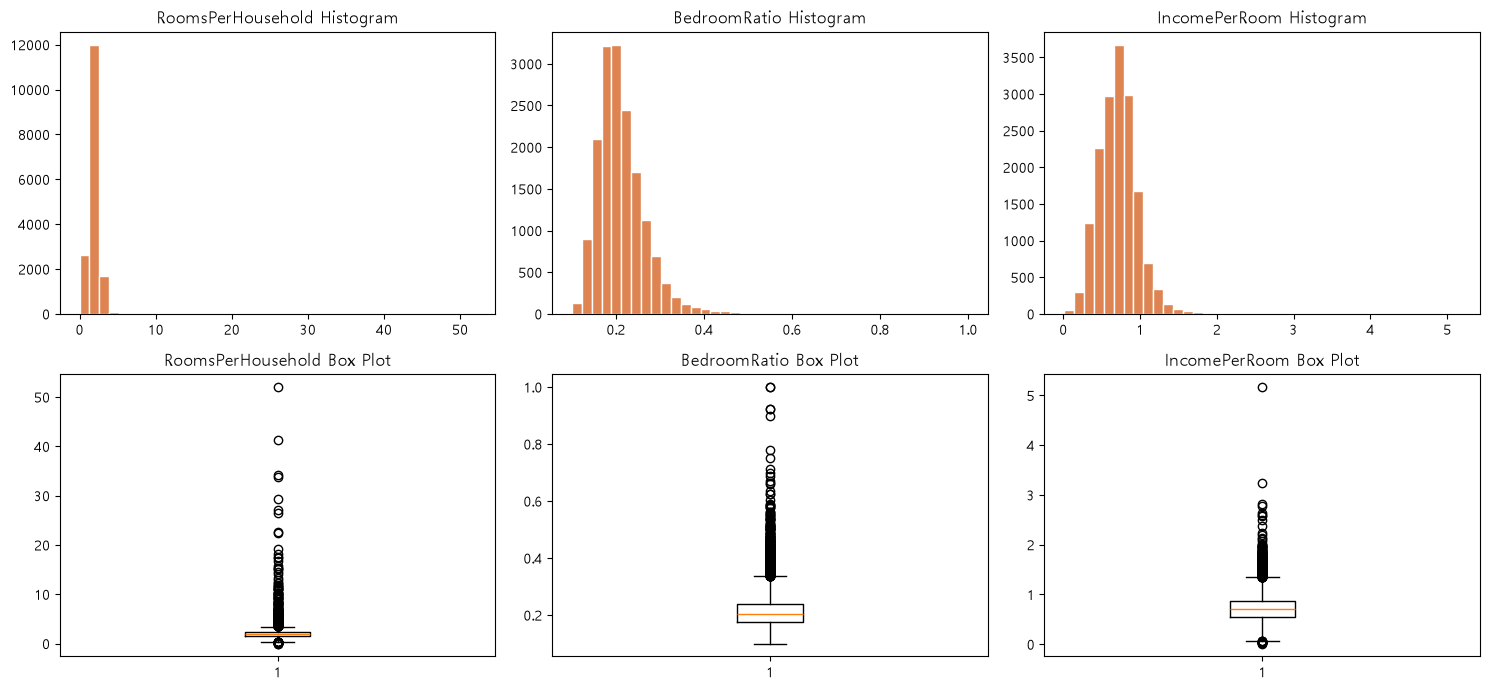

In [64]:
ratio_cols_to_plot = [
    "RoomsPerHousehold",
    "BedroomRatio",
    "IncomePerRoom"
]
fig, axes = plt.subplots(2, 3, figsize=(15, 7))

for i, col in enumerate(ratio_cols_to_plot):

    # Histogram
    axes[0, i].hist(
        X_train_engineered[col],
        bins=40,
        color="#DD8452",
        edgecolor="white"
    )
    axes[0, i].set_title(f"{col} Histogram")

    # Box Plot
    axes[1, i].boxplot(
        X_train_engineered[col],
        orientation="vertical"
    )
    axes[1, i].set_title(f"{col} Box Plot")

plt.tight_layout()
plt.show()

**해석**: `RoomsPerHousehold`, `BedroomRatio`는 대체로 안정적인 범위에 분포하지만,
`IncomePerRoom`과 `PopulationPerHousehold`는 `AveRooms`/`AveOccup`가 작은 일부
지역에서 큰 이상치를 만들어냅니다. 원본 Feature의 이상치(Finding 4)가 파생변수에도
그대로 전파된다는 점을 알 수 있습니다.

## 12. Feature 적용 모델

Baseline과 정확히 동일한 `train_test_split` 결과(같은 행 구성), 동일한 `random_state`,
동일한 `n_estimators`를 사용해 Feature Engineering을 적용한 데이터로 다시 학습합니다.
모델 조건을 동일하게 유지해야 Feature Engineering 효과만 공정하게 비교할 수 있습니다.

In [66]:
# # 중복 컬럼 찾기
# dup_cols = X_train_engineered.columns[
#     X_train_engineered.columns.duplicated()
# ]

# print(dup_cols.tolist())

X_train_fe = X_train_engineered[ALL_COLUMNS]
X_test_fe = X_test_engineered[ALL_COLUMNS]

feature_model = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)
feature_model.fit(X_train_fe, y_train)
feature_pred = feature_model.predict(X_test_fe)

feature_metrics = evaluate(y_test, feature_pred)
feature_result = {"Model": "Feature Engineering", **feature_metrics}
pd.DataFrame([feature_result])

,Model,MAE,RMSE,R2
0,Feature Engineering,0.325369,0.498423,0.810421


## 13. 모델 성능 비교

- `MAE`, `RMSE`는 **낮을수록** 좋습니다.
- `R2`는 **높을수록** 좋습니다.
- 성능 차이가 매우 작다면 Feature가 반드시 유용하다고 단정하지 말아야 합니다.

In [67]:
comparison_df = pd.DataFrame([baseline_result, feature_result])

mae_improvement = (baseline_result["MAE"] - feature_result["MAE"]) / baseline_result["MAE"] * 100
rmse_improvement = (baseline_result["RMSE"] - feature_result["RMSE"]) / baseline_result["RMSE"] * 100
r2_change = feature_result["R2"] - baseline_result["R2"]

print(f"MAE 개선율: {mae_improvement:.2f}%")
print(f"RMSE 개선율: {rmse_improvement:.2f}%")
print(f"R2 변화량: {r2_change:+.4f}")

comparison_df

MAE 개선율: 0.44%
RMSE 개선율: 1.16%
R2 변화량: +0.0045


,Model,MAE,RMSE,R2
0,Baseline,0.326790,0.504290,0.805932
1,Feature Engineering,0.325369,0.498423,0.810421


## 14. 단계별 Feature 실험

모든 Feature를 한 번에 추가하면 "어떤 Feature가 실제로 효과가 있었는지" 알기
어렵습니다. 그래서 Feature를 하나씩 누적해서 추가하며 성능 변화를 관찰합니다.

- 실험 A: `RoomsPerHousehold`만 추가
- 실험 B: `RoomsPerHousehold` + `BedroomRatio`
- 실험 C: 위 Feature + `IncomePerRoom` + `PopulationPerHousehold`
- 실험 D: 위 Feature + `HouseAgeGroup`
- 실험 E: 위 Feature + `LocationCluster`
- 실험 F: 모든 Feature 적용 (Section 12의 Feature 적용 모델과 동일)

In [ ]:
experiments: dict[str, list[str]] = {
    "A. +RoomsPerHousehold": ["RoomsPerHousehold"],
    "B. +BedroomRatio": ["RoomsPerHousehold", "BedroomRatio"],
    "C. +IncomePerRoom/PopulationPerHousehold": [
        "RoomsPerHousehold", "BedroomRatio", "IncomePerRoom", "PopulationPerHousehold",
    ],
    "D. +HouseAgeGroup": (
        ["RoomsPerHousehold", "BedroomRatio", "IncomePerRoom", "PopulationPerHousehold"]
        + HOUSE_AGE_DUMMY_COLUMNS
    ),
    "E. +LocationCluster": (
        ["RoomsPerHousehold", "BedroomRatio", "IncomePerRoom", "PopulationPerHousehold"]
        + HOUSE_AGE_DUMMY_COLUMNS
        + ["LocationCluster"]
    ),
    "F. 모든 Feature 적용": ALL_ENGINEERED_FEATURES,
}

experiment_rows = [dict(baseline_result, Model="Baseline (원본 8개)")]
for name, extra_cols in experiments.items():
    cols = FEATURE_COLUMNS + extra_cols
    model = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)
    model.fit(X_train_fe[cols], y_train)
    pred = model.predict(X_test_fe[cols])
    metrics = evaluate(y_test, pred)
    experiment_rows.append({"Model": name, **metrics})

experiment_results_df = pd.DataFrame(experiment_rows)
experiment_results_df

**해석**: 각 실험의 `MAE`/`RMSE`/`R2` 변화를 Baseline과 비교하면, 어떤 단계에서
성능이 크게 개선되었는지(또는 거의 변하지 않았는지) 확인할 수 있습니다. 실험 F는
Section 12의 "Feature 적용 모델"과 동일한 Feature 조합이므로 같은 결과가 나오는
것이 정상입니다.

## 15. Feature Importance

최종(Section 12) RandomForest 모델의 Feature Importance를 확인합니다. 중요도가
높다고 해서 그 Feature가 집값을 "일으키는 원인"이라는 뜻은 아닙니다. 어디까지나
이 모델이 예측할 때 얼마나 자주/크게 활용했는지를 나타내는 지표입니다.

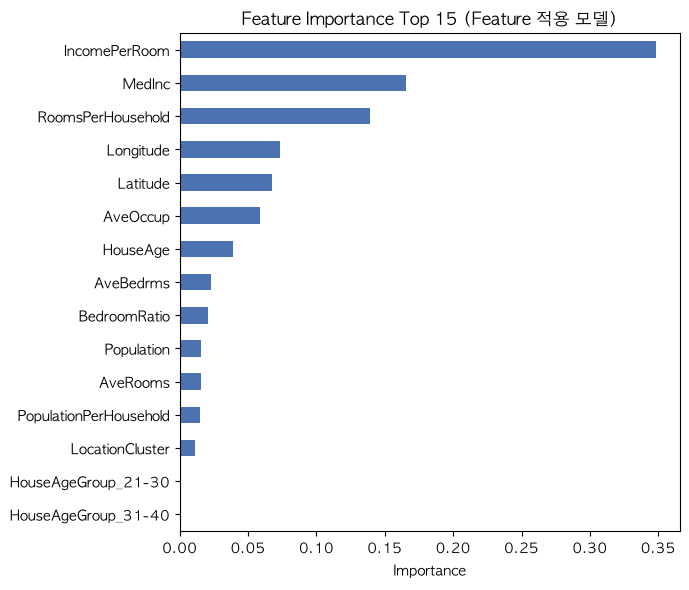

IncomePerRoom             0.348485
MedInc                    0.165227
RoomsPerHousehold         0.139354
Longitude                 0.073251
Latitude                  0.067652
AveOccup                  0.059017
HouseAge                  0.039052
AveBedrms                 0.023137
BedroomRatio              0.020823
Population                0.015918
AveRooms                  0.015470
PopulationPerHousehold    0.015133
LocationCluster           0.011148
HouseAgeGroup_21-30       0.001210
HouseAgeGroup_31-40       0.001140
dtype: float64

In [72]:
importances = pd.Series(feature_model.feature_importances_, index=ALL_COLUMNS)
top15 = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(7, 6))
top15.sort_values().plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_title("Feature Importance Top 15 (Feature 적용 모델)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

top15

In [73]:
original_top = importances[FEATURE_COLUMNS].sort_values(ascending=False)
engineered_top = importances[ALL_ENGINEERED_FEATURES].sort_values(ascending=False)

print("원본 Feature 중요도:")
print(original_top)
print()
print("새로 만든 Feature 중요도:")
print(engineered_top)

원본 Feature 중요도:
MedInc        0.165227
Longitude     0.073251
Latitude      0.067652
AveOccup      0.059017
HouseAge      0.039052
AveBedrms     0.023137
Population    0.015918
AveRooms      0.015470
dtype: float64

새로 만든 Feature 중요도:
IncomePerRoom             0.348485
RoomsPerHousehold         0.139354
BedroomRatio              0.020823
PopulationPerHousehold    0.015133
LocationCluster           0.011148
HouseAgeGroup_21-30       0.001210
HouseAgeGroup_31-40       0.001140
HouseAgeGroup_11-20       0.001046
HouseAgeGroup_41-50       0.000961
HouseAgeGroup_51+         0.000861
HouseAgeGroup_0-10        0.000422
LuxuryHouseCandidate      0.000406
HighIncomeArea            0.000286
dtype: float64


**해석**:
- 원본 Feature 중에서는 `MedInc`, `Latitude`, `Longitude`가 꾸준히 높은 중요도를 보입니다.
- 새로 만든 Feature 중에서는 `IncomePerRoom`, `RoomsPerHousehold`처럼 `MedInc`/`AveRooms`와
  직접 연관된 비율 Feature가 상대적으로 높은 중요도를 보이는 경향이 있습니다.
- `HighIncomeArea`, `LuxuryHouseCandidate`처럼 이미 있는 정보를 이진화(threshold)한
  Feature는 원본 연속값이 이미 존재하므로 중요도가 낮게 나오는 경향이 있습니다.
- **중요도가 높다고 해서 인과관계를 의미하지는 않습니다.** RandomForest는 예측 성능에
  얼마나 기여했는지를 측정할 뿐, "왜" 그런 관계가 있는지는 설명하지 않습니다.

## 16. 최종 Feature 선택

> **주의**: 아래 표의 "결과"/"판단"은 위에서 계산한 상관계수·단계별 실험·Feature
> Importance 결과를 근거로 채워야 합니다. 이 셀 바로 아래 코드 셀에서 실제 수치를
> 다시 한 번 요약해서 보여주므로, 표의 판단이 그 수치와 일치하는지 항상 확인하세요.

| Feature | 결과 | 판단 | 이유 |
|---|---|---|---|
| `RoomsPerHousehold` | Target 상관 양의 방향, Importance 상위권 | **채택** | "공간 여유도"라는 새 정보를 제공하고 중요도도 높다 |
| `IncomePerRoom` | Target과 상관 강함, Importance 상위권 | **채택** | `MedInc`만으로는 못 담는 방 수 대비 소득 정보를 제공한다 |
| `BedroomRatio` | Target과 음의 상관(중간 수준), 새 Feature 중 Importance 3위지만 단계별 실험(B)에서는 성능 개선이 거의 없음 | **보류** | 단독 신호는 있으나 원본(`AveRooms`,`AveBedrms`) 대비 실제 성능 기여가 작다 |
| `PopulationPerHousehold` | 극단적 이상치 존재, Target 상관 약함, Importance 낮음 | **보류** | 해석이 간접적이고(인구밀도 아님) 이상치 영향을 받기 쉽다 |
| `HouseAgeGroup_*` | 단계별 실험(D)에서 성능이 거의 변하지 않거나 오히려 소폭 하락 | **보류** | `HouseAge` 원본이 이미 있어 구간화의 추가 효과가 제한적 |
| `LocationCluster` | 단계별 실험(E)에서 성능 개선 확인, Importance 존재 | **채택** | `Latitude`/`Longitude` 개별 값보다 지역 단위 정보를 직접 제공한다 |
| `HighIncomeArea` | Importance 최하위권 | **제외 후보** | `MedInc` 원본 값과 정보가 중복되어 이진화로 인한 정보 손실이 더 큼 |
| `LuxuryHouseCandidate` | Importance 최하위권, 표본 수 적음 | **제외 후보** | 조건을 만족하는 지역이 적어 학습에 미치는 영향이 미미하다 |

실제 수치는 아래 코드 셀에서 다시 확인하세요.